# Sistem Case-Based Reasoning (CBR) untuk Pencarian Putusan Pengadilan

Notebook ini merupakan implementasi **Tahap 1 - Case Base Construction**
dalam sistem Case-Based Reasoning (CBR).

Tahapan yang dilakukan meliputi:

- Membaca dokumen putusan (.pdf)
- Mengekstrak isi dokumen
- Membersihkan teks
- Menghasilkan dataset awal yang siap diproses pada tahap berikutnya.

## Instalasi Library

Jalankan cell berikut apabila library belum terpasang pada lingkungan Python atau Google Colab.

Library yang digunakan:

- pdfplumber → ekstraksi teks PDF
- pandas → manipulasi dataset
- numpy → komputasi numerik
- scikit-learn → TF-IDF, Cosine Similarity, evaluasi
- matplotlib → visualisasi
- seaborn → visualisasi statistik
- Sastrawi → stemming Bahasa Indonesia

In [1]:
!pip install pdfplumber pandas numpy scikit-learn matplotlib seaborn Sastrawi


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Library

Mengimpor seluruh library yang dibutuhkan selama proses preprocessing dokumen.

In [2]:
# Built-in Libraries
import os
import re
import json
import pickle
import logging

from pathlib import Path
from datetime import datetime
from typing import List, Dict

# Data Processing
import pandas as pd
import numpy as np

# PDF Processing
import pdfplumber

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_folder = Path("data")

files = list(data_folder.glob("*"))

print(f"Jumlah file: {len(files)}")

for file in files[:5]:
    print(file.name)

Jumlah file: 32
putusan_150_pid.sus_2024_pn_bks_20260624223605.pdf
putusan_19_pid.sus_2026_pn_bks_20260624222523.pdf
putusan_1_pid.sus_2020_pn_bks_20260624223152.pdf
putusan_236_pid.sus_2021_pn_bks_20260624223553.pdf
putusan_261_pid.sus_2018_pn_bks_20260624223818.pdf


## Ekstraksi Dokumen PDF ke Format Teks

Pada tahap ini dilakukan proses **ekstraksi teks** dari seluruh dokumen putusan pengadilan yang masih berformat **PDF** menjadi file **TXT**. Proses ini merupakan bagian dari pembangunan *Case Base* yang akan digunakan pada tahap-tahap berikutnya.

Fitur yang dijalankan pada tahap ini meliputi:

- Mengatur konfigurasi *logging* untuk memantau proses ekstraksi.
- Menentukan lokasi folder dataset, folder output, dan penyimpanan statistik.
- Mengekstrak seluruh isi teks dari setiap dokumen PDF menggunakan **pdfplumber**.
- Menyimpan hasil ekstraksi ke dalam folder `data/raw/`.
- Menghitung statistik setiap dokumen, meliputi:
  - jumlah halaman,
  - jumlah karakter,
  - jumlah kata.
- Menyimpan statistik ekstraksi ke dalam file `logs/extraction_stats.csv`.
- Melakukan *batch processing* sehingga seluruh dokumen dapat diproses secara otomatis.

Output yang dihasilkan pada tahap ini adalah kumpulan file `.txt` yang siap digunakan pada proses **preprocessing** pada tahap selanjutnya.

In [4]:
# ============================================================
# SETUP LOGGING
# ============================================================
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s'
)
logger = logging.getLogger(__name__)

# ============================================================
# KONFIGURASI
# ============================================================
PDF_FOLDER = "data"
OUTPUT_FOLDER = "data/raw"
STATS_FILE = "logs/extraction_stats.csv"

Path(OUTPUT_FOLDER).mkdir(parents=True, exist_ok=True)
Path("logs").mkdir(parents=True, exist_ok=True)

# ============================================================
# FUNGSI EKSTRAKSI + STATISTIK
# ============================================================
def extract_pdf_to_txt(pdf_path: str, output_txt_path: str) -> dict:
    """
    Ekstrak teks dari PDF dan kembalikan statistik
    """
    stats = {
        "filename": Path(pdf_path).name,
        "status": "failed",
        "char_count": 0,
        "word_count": 0,
        "page_count": 0
    }
    
    try:
        with pdfplumber.open(pdf_path) as pdf:
            full_text = ""
            stats["page_count"] = len(pdf.pages)
            
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    full_text += page_text + "\n"
            
            if not full_text.strip():
                logger.warning(f"⚠️  Tidak ada teks yang diekstrak dari {Path(pdf_path).name}")
                return stats
            
            # Simpan teks
            with open(output_txt_path, "w", encoding="utf-8") as f:
                f.write(full_text)
            
            # === UPDATE: Hitung statistik ===
            char_count = len(full_text)
            word_count = len(full_text.split())
            
            stats.update({
                "status": "success",
                "char_count": char_count,
                "word_count": word_count
            })
            
            # Print statistik (seperti yang kamu minta)
            print(f"📄 {Path(pdf_path).name}")
            print(f"   Jumlah karakter : {char_count:,}")
            print(f"   Jumlah kata     : {word_count:,}")
            print(f"   Jumlah halaman  : {stats['page_count']}")
            print("-" * 50)
            
            logger.info(f"✅ Berhasil diekstrak: {Path(pdf_path).name}")
            return stats
            
    except Exception as e:
        logger.error(f"❌ Gagal memproses {Path(pdf_path).name}: {str(e)}")
        return stats

# ============================================================
# BATCH PROCESSING (Loop 0 sampai 31)
# ============================================================
def batch_extract_pdfs(pdf_folder: str, output_folder: str, start: int = 0, end: int = 31):
    pdf_files = sorted([f for f in os.listdir(pdf_folder) if f.lower().endswith('.pdf')])
    
    if not pdf_files:
        logger.error(f"Tidak ada file PDF di folder: {pdf_folder}")
        return
    
    total = len(pdf_files)
    logger.info(f"Total PDF ditemukan: {total}")
    logger.info(f"Memproses dari index {start} sampai {min(end, total-1)}")
    
    all_stats = []
    success_count = 0
    
    for idx in range(start, min(end + 1, total)):
        pdf_file = pdf_files[idx]
        pdf_path = os.path.join(pdf_folder, pdf_file)
        
        case_number = str(idx + 1).zfill(3)
        output_txt = os.path.join(output_folder, f"case_{case_number}.txt")
        
        stats = extract_pdf_to_txt(pdf_path, output_txt)
        all_stats.append(stats)
        
        if stats["status"] == "success":
            success_count += 1
    
    # Simpan statistik ke CSV
    stats_df = pd.DataFrame(all_stats)
    stats_df.to_csv(STATS_FILE, index=False, encoding="utf-8-sig")
    
    # Ringkasan
    logger.info("=" * 60)
    logger.info(f"PROSES SELESAI")
    logger.info(f"Berhasil diekstrak : {success_count}/{total - start}")
    logger.info(f"Statistik disimpan : {STATS_FILE}")
    logger.info("=" * 60)
    
    return stats_df

# ============================================================
# JALANKAN
# ============================================================
if __name__ == "__main__":
    batch_extract_pdfs(
        pdf_folder=PDF_FOLDER,
        output_folder=OUTPUT_FOLDER,
        start=0,
        end=31
    )

2026-06-27 16:09:45,555 | INFO | Total PDF ditemukan: 32
2026-06-27 16:09:45,556 | INFO | Memproses dari index 0 sampai 31
2026-06-27 16:09:47,549 | INFO | ✅ Berhasil diekstrak: putusan_150_pid.sus_2024_pn_bks_20260624223605.pdf


📄 putusan_150_pid.sus_2024_pn_bks_20260624223605.pdf
   Jumlah karakter : 74,858
   Jumlah kata     : 14,200
   Jumlah halaman  : 22
--------------------------------------------------


2026-06-27 16:09:49,352 | INFO | ✅ Berhasil diekstrak: putusan_19_pid.sus_2026_pn_bks_20260624222523.pdf


📄 putusan_19_pid.sus_2026_pn_bks_20260624222523.pdf
   Jumlah karakter : 63,055
   Jumlah kata     : 12,128
   Jumlah halaman  : 20
--------------------------------------------------


2026-06-27 16:09:50,342 | INFO | ✅ Berhasil diekstrak: putusan_1_pid.sus_2020_pn_bks_20260624223152.pdf


...

📄 putusan_635_pid.sus_2019_pn_bks_20260624223204.pdf
   Jumlah karakter : 97,239
   Jumlah kata     : 18,456
   Jumlah halaman  : 28
--------------------------------------------------


2026-06-27 16:10:48,473 | INFO | ✅ Berhasil diekstrak: putusan_733_pid.sus_2021_pn_bks_20260624223829.pdf


📄 putusan_733_pid.sus_2021_pn_bks_20260624223829.pdf
   Jumlah karakter : 30,844
   Jumlah kata     : 5,905
   Jumlah halaman  : 10
--------------------------------------------------


2026-06-27 16:10:49,778 | INFO | ✅ Berhasil diekstrak: putusan_741_pid.sus_2020_pn_bks_20260624222915.pdf
2026-06-27 16:10:49,840 | INFO | ✅ Berhasil diekstrak: putusan_829_pid.sus_2019_pn_bks_20260624223140.pdf
2026-06-27 16:10:49,867 | INFO | ============================================================
2026-06-27 16:10:49,867 | INFO | PROSES SELESAI
2026-06-27 16:10:49,868 | INFO | Berhasil diekstrak : 32/32
2026-06-27 16:10:49,868 | INFO | Statistik disimpan : logs/extraction_stats.csv
2026-06-27 16:10:49,868 | INFO | ============================================================


📄 putusan_741_pid.sus_2020_pn_bks_20260624222915.pdf
   Jumlah karakter : 43,211
   Jumlah kata     : 8,122
   Jumlah halaman  : 13
--------------------------------------------------
📄 putusan_829_pid.sus_2019_pn_bks_20260624223140.pdf
   Jumlah karakter : 1,863
   Jumlah kata     : 433
   Jumlah halaman  : 1
--------------------------------------------------


## Pembangunan Case Base (Case Representation)

Pada tahap ini dilakukan proses pembangunan **Case Base** yang akan menjadi sumber data utama dalam sistem **Case-Based Reasoning (CBR)**. Seluruh dokumen hasil ekstraksi yang masih berupa file `.txt` akan diproses sehingga menghasilkan dataset yang terstruktur dan siap digunakan pada tahap pencarian kasus (*Case Retrieval*).

Tahapan yang dilakukan meliputi:

- Mengatur konfigurasi **logging** untuk mencatat seluruh proses pemrosesan dokumen.
- Mengidentifikasi dan menghapus **noise** yang berasal dari proses OCR, seperti watermark, header, footer, karakter acak, dan token yang tidak relevan.
- Melakukan **preprocessing** terhadap isi putusan dengan normalisasi teks serta perbaikan kesalahan hasil OCR menggunakan pendekatan *rule-based*.
- Mengekstrak **metadata perkara**, seperti nomor perkara, tanggal putusan, jenis perkara, pasal yang digunakan, serta identitas terdakwa atau para pihak.
- Mengekstrak **fitur-fitur penting** dari setiap putusan, seperti ringkasan fakta, argumen hukum utama, amar putusan, dan potongan isi dokumen.
- Menggabungkan seluruh metadata dan fitur menjadi sebuah **Case Base** yang terstruktur.
- Menyimpan hasil akhir ke dalam format **CSV** (`cases.csv`) dan **JSON** (`cases.json`) pada folder `data/processed/`.
- Menampilkan ringkasan hasil pemrosesan serta menyimpan log aktivitas ke dalam folder `logs/`.

Dataset yang dihasilkan pada tahap ini akan digunakan sebagai dasar representasi kasus pada proses **TF-IDF**, **Cosine Similarity**, dan pencarian kasus yang memiliki tingkat kemiripan tertinggi pada tahap berikutnya.

In [5]:
# ============================================================
# CBR - CASE BASE PIPELINE
# ============================================================


# ============================================================
# SETUP LOGGING
# ============================================================
def setup_logging(log_dir: str = "logs"):
    Path(log_dir).mkdir(parents=True, exist_ok=True)
    log_file = Path(log_dir) / "cleaning.log"

    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s | %(levelname)s | %(message)s',
        handlers=[
            logging.FileHandler(log_file, encoding='utf-8'),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)


logger = setup_logging()


# ============================================================
# HELPER: Deteksi apakah sebuah token adalah "noise" OCR
# Token dianggap noise jika: panjang <= 2 DAN bukan angka/kata umum
# ============================================================
VALID_SHORT_TOKENS = {
    # Kata pendek Indonesia yang valid
    'di', 'ke', 'dari', 'dan', 'atau', 'yang', 'ia', 'ia', 'si',
    'RI', 'No', 'ID', 'UU', 'KD', 'SH', 'MH', 'SW',
    # Angka romawi
    'I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X',
    # Singkatan umum
    'RT', 'RW', 'Ds', 'Kp', 'Kel', 'Kec', 'Kab', 'CV', 'PT', 'PN',
}

def is_noise_token(token: str) -> bool:
    """Kembalikan True jika token adalah karakter noise OCR."""
    if token in VALID_SHORT_TOKENS:
        return False
    if re.match(r'^\d+$', token):      # murni angka -> bukan noise
        return False
    if re.match(r'^\d+[a-zA-Z]$', token):  # contoh: "2b", "200b4" -> noise ringan, biarkan
        return False
    # Token 1-2 karakter huruf saja -> noise
    if len(token) <= 2 and re.match(r'^[a-zA-Z]+$', token):
        return True
    return False


# ============================================================
# TAHAP 0: PERBAIKAN PRA-BARIS
# Tangani karakter noise OCR yang MENEMPEL di baris konten valid
# ============================================================
def strip_inline_noise(line: str) -> str:
    """
    Hapus karakter OCR noise yang menempel di awal/akhir atau tersebar
    di antara konten valid dalam satu baris.

    Strategi:
    - Tokenisasi per spasi
    - Buang token yang murni 1-2 huruf noise dari posisi AWAL dan AKHIR baris
    - Untuk token noise di TENGAH: hanya hapus jika diapit konten panjang
    """
    tokens = line.split()
    if not tokens:
        return ''

    # Strip dari kiri
    while tokens and is_noise_token(tokens[0]):
        tokens.pop(0)

    # Strip dari kanan
    while tokens and is_noise_token(tokens[-1]):
        tokens.pop()

    if not tokens:
        return ''

    # Hapus noise di tengah jika diapit kata panjang (lebih konservatif)
    cleaned = []
    for i, tok in enumerate(tokens):
        if is_noise_token(tok):
            # Cek apakah tetangga kiri dan kanan adalah kata panjang (>= 4 char)
            left_ok  = (i > 0 and len(tokens[i-1]) >= 4)
            right_ok = (i < len(tokens)-1 and len(tokens[i+1]) >= 4)
            if left_ok and right_ok:
                continue  # buang token noise di tengah
            # Jika tidak diapit kata panjang, biarkan (mungkin bagian dari konteks)
        cleaned.append(tok)

    return ' '.join(cleaned)


# ============================================================
# 1. PREPROCESSING TEKS (IMPROVED)
# ============================================================
def preprocess_text(text: str, file_name: str) -> str:
    original_lines = text.splitlines()
    original_words = len(text.split())

    # ----------------------------------------------------------
    # DAFTAR POLA YANG HARUS DIHAPUS (header/footer/disclaimer)
    # ----------------------------------------------------------
    SKIP_PATTERNS = [
        r'Direktori Putusan Mahkamah Agung',
        r'putusan\.mahkamahagung\.go\.id',
        r'Kepaniteraan Mahkamah Agung',
        r'Disclaimer',
        r'berusaha untuk selalu mencantumkan',
        r'tau informasi yang seharusnya ada',
        r'D\s+Em\s+al\s+a\s+am\s+il',      # pola watermark diagonal
        r'kepaniteraan@mahkamahagung',
        r'Halaman\s+\d+\s+dari\s+\d+\s+halaman',
    ]
    SKIP_RE = [re.compile(p, re.IGNORECASE) for p in SKIP_PATTERNS]

    # ----------------------------------------------------------
    # TAHAP 1: Filter per baris
    # ----------------------------------------------------------
    cleaned_lines = []
    removed_count = 0

    for raw_line in original_lines:
        line = raw_line.strip()

        # 1a. Baris kosong
        if not line:
            removed_count += 1
            continue

        # 1b. Baris yang cocok dengan pola skip
        if any(pat.search(line) for pat in SKIP_RE):
            removed_count += 1
            continue

        # 1c. Baris yang SELURUHNYA terdiri dari karakter noise OCR
        #     (pola watermark vertikal: tiap baris cuma 1 huruf atau 2 huruf)
        tokens = line.split()
        total_tokens = len(tokens)

        if total_tokens == 0:
            removed_count += 1
            continue

        noise_count = sum(1 for t in tokens if is_noise_token(t))

        # Jika >= 80% token adalah noise -> buang seluruh baris
        if total_tokens > 0 and (noise_count / total_tokens) >= 0.80:
            removed_count += 1
            continue

        # 1d. Baris 1 token dengan 1 karakter saja (watermark vertikal)
        if total_tokens == 1 and len(tokens[0]) <= 2 and re.match(r'^[a-zA-Z]+$', tokens[0]):
            removed_count += 1
            continue

        # 1e. Hapus noise yang menempel di pinggir/tengah baris yang masih valid
        line = strip_inline_noise(line)
        if not line:
            removed_count += 1
            continue

        cleaned_lines.append(line)

    text = ' '.join(cleaned_lines)

    # ----------------------------------------------------------
    # TAHAP 2: Normalisasi OCR (spasi, karakter acak)
    # ----------------------------------------------------------

    # Perbaiki huruf yang "melayang" sendirian di antara kata (lebih agresif)
    # Contoh: "tanggal 17 Desember n 2023" -> "tanggal 17 Desember 2023"
    # Hanya hapus jika diapit spasi dan bukan angka romawi / singkatan valid
    def remove_floating_chars(m):
        token = m.group(1)
        if token in VALID_SHORT_TOKENS:
            return m.group(0)  # pertahankan
        return ' '

    text = re.sub(r'\s+([a-zA-Z])\s+', remove_floating_chars, text)
    text = re.sub(r'\s+([a-zA-Z])\s+', remove_floating_chars, text)  # dua kali untuk kasus beruntun

    # Perbaiki "P U T U S A N" -> "PUTUSAN"
    text = re.sub(r'P\s+U\s+T\s+U\s+S\s+A\s+N', 'PUTUSAN', text)

    # ----------------------------------------------------------
    # TAHAP 3: OCR Corrections
    # ----------------------------------------------------------
    corrections = [
        # Typo umum dari OCR
        (r'\bpoerkara\b',           'perkara'),
        (r'\bpidapna\b',            'pidana'),
        (r'\bwuaktu\b',             'waktu'),
        (r'\btadnggal\b',           'tanggal'),
        (r'\btangngal\b',           'tanggal'),
        (r'\btangugal\b',           'tanggal'),
        (r'\bberangkas\b',          'brangkas'),
        (r'\bJenis Kelamnin\b',     'Jenis Kelamin'),
        (r'\bPekerjaann\b',         'Pekerjaan'),
        (r'\bPenuntut Umuml\b',     'Penuntut Umum'),
        (r'\bterd akwa\b',          'terdakwa'),
        (r'\busecara\b',            'secara'),
        (r'\bUndang-Und ang\b',     'Undang-Undang'),
        (r'\bsebaRgian\b',          'sebagian'),
        (r'\bMuenimbang\b',         'Menimbang'),
        (r'\bTerdakwda\b',          'Terdakwa'),
        (r'\bbarang siapla\b',      'barang siapa'),
        (r'\bmeunguntungkan\b',     'menguntungkan'),
        (r'\bpseseorang\b',         'seseorang'),
        (r'\batnau\b',              'atau'),
        (r'\bdiuancam\b',           'diancam'),
        (r'\bsamppai\b',            'sampai'),
        (r'\bJanuurari\b',          'Januari'),
        (r'\bJanuuari\b',           'Januari'),
        (r'\bJanuarki\b',           'Januari'),
        (r'\bPernpanjangan\b',      'Perpanjangan'),
        (r'\bsejapk\b',             'sejak'),
        (r'\bdiitahan\b',           'ditahan'),
        (r'\bTnahanan\b',           'Tahanan'),
        (r'\bAgunag\b',             'Agung'),
        (r'\buintuk\b',             'untuk'),
        (r'\bklami\b',              'kami'),
        (r'\bMajeplis\b',           'Majelis'),
        (r'\bperbuatnan\b',         'perbuatan'),
        (r'\bmendidiku\b',          'mendidik'),
        (r'\bkesalahanonya\b',      'kesalahannya'),
        (r'\bdip\s+ertimbangkan\b', 'dipertimbangkan'),
        (r'\blainn\b',              'lain'),
        (r'\bbaragng\b',            'barang'),
        (r'\bdibanltu\b',           'dibantu'),
        (r'\bKejaksaaan\b',         'Kejaksaan'),
        (r'\bHukumpnya\b',          'Hukumnya'),
        (r'\bsReluruhnya\b',        'seluruhnya'),
        (r'\bbguah\b',              'buah'),
        (r'\bsgenjata\b',           'senjata'),
        (r'\bberwarnea\b',          'berwarna'),
        (r'\bLRevis\b',             'Levis'),
        (r'\bkareuna\b',            'karena'),
        (r'\bkparena\b',            'karena'),
        (r'\bperbuatanb\b',         'perbuatan'),
        (r'\bIndonelsia\b',         'Indonesia'),
        # Tanggal/tahun dengan karakter sisipan: "202 4" -> "2024", "200b4" -> "2004"
        (r'\b(\d{3})\s+(\d)\b',     r'\1\2'),
        (r'\b(\d{3})b(\d)\b',       r'\1\2'),
    ]

    for pattern, replacement in corrections:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    # Normalisasi spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # ----------------------------------------------------------
    # VALIDASI RETENSI
    # ----------------------------------------------------------
    cleaned_words = len(text.split())
    retention_rate = (cleaned_words / original_words * 100) if original_words > 0 else 0

    if retention_rate < 80:
        logger.warning(
            f"[{file_name}] Retensi {retention_rate:.1f}% ({cleaned_words}/{original_words} kata) "
            f"— di bawah 80%, kemungkinan file sumber memiliki banyak watermark/karakter OCR vertikal. "
            f"Periksa kualitas file .txt atau gunakan alat PDF-to-text yang lebih baik (pdfplumber/pdftotext)."
        )
    else:
        logger.info(
            f"[{file_name}] Retensi baik: {retention_rate:.1f}% "
            f"({cleaned_words}/{original_words} kata)"
        )

    logger.info(f"[{file_name}] Dihapus ±{removed_count} baris noise/header/footer")

    return text


# ============================================================
# 2. EKSTRAKSI METADATA
# ============================================================
def extract_metadata(text: str, file_name: str) -> Dict:
    meta = {}
    meta['case_id'] = file_name.replace('.txt', '')

    # Nomor perkara — coba beberapa pola dari yang paling spesifik
    patterns_no = [
        r'Nomor\s*:?\s*(\d+/[A-Za-z.]+/\d{4}/[A-Za-z]+\s+\w+)',   # "150/Pid.Sus/2024/PN Bks"
        r'Nomor\s*:?\s*(\d+/[A-Za-z.]+/\d{4}/[A-Za-z]+)',          # tanpa kota
        r'Nomor\s*:?\s*(\d+/\w+/\d{4})',                            # fallback singkat
    ]
    meta['no_perkara'] = None
    for pat in patterns_no:
        match = re.search(pat, text, re.IGNORECASE)
        if match:
            meta['no_perkara'] = match.group(1).strip()
            break

    # Tanggal putusan (cari yang paling spesifik: tanggal sidang/putusan)
    match = re.search(
        r'(?:diputuskan|tanggal)\s+(?:dalam\s+sidang\s+[^,]+,\s+pada\s+hari\s+\w+,\s+tanggal\s+)?'
        r'(\d{1,2}\s+\w+\s+\d{4})',
        text, re.IGNORECASE
    )
    meta['tanggal'] = match.group(1) if match else None

    # Jenis perkara (berdasarkan pasal & konten)
    if re.search(r'Narkotika|Psikotropika|narkoba', text, re.IGNORECASE):
        meta['jenis_perkara'] = 'Pidana Khusus Narkotika & Psikotropika'
    elif re.search(r'Wanprestasi|Perbuatan Melawan Hukum', text, re.IGNORECASE):
        meta['jenis_perkara'] = 'Perdata Wanprestasi'
    elif re.search(r'pemerasan|pencurian|penggelapan|penipuan', text, re.IGNORECASE):
        meta['jenis_perkara'] = 'Pidana Umum'
    else:
        meta['jenis_perkara'] = 'Lainnya'

    # Pasal yang digunakan
    pasal = re.findall(
        r'Pasal\s+\d+(?:\s+[Aa]yat\s+\([^)]+\))?(?:\s+[Jj][Oo]\.?\s+Pasal\s+\d+[^.]*?)?'
        r'(?:KUHP|KUHPidana|Undang-Undang|UU)',
        text, re.IGNORECASE
    )
    meta['pasal'] = list(dict.fromkeys(pasal))[:8]  # deduplikasi + max 8

    # Nama terdakwa (ambil semua)
    terdakwa = re.findall(r'(?:terdakwa\s+(?:I{1,4}V?|[1-4])\s*[.\):]?\s*)([A-Z][A-Z\s]+(?:als\s+\w+)?)', text)
    meta['terdakwa'] = list(dict.fromkeys([t.strip() for t in terdakwa]))[:4]

    # Pihak penggugat & tergugat (perdata)
    penggugat = re.findall(r'Penggugat\s*:\s*([^;.]+)', text, re.IGNORECASE)
    tergugat  = re.findall(r'Tergugat\s*:\s*([^;.]+)', text, re.IGNORECASE)
    meta['pihak_penggugat'] = penggugat[0].strip() if penggugat else None
    meta['pihak_tergugat']  = tergugat[0].strip() if tergugat else None

    return meta


# ============================================================
# 3. EKSTRAKSI FEATURE
# ============================================================
def extract_features(text: str) -> Dict:
    feat = {}
    feat['text_length'] = len(text.split())

    # Ringkasan fakta
    fakta = re.search(
        r'(?:Bahwa ia terdakwa|Bahwa Para Terdakwa|Bahwa pada)(.*?)'
        r'(?=Perbuatan terdakwa|Menimbang, bahwa|MENGADILI)',
        text, re.DOTALL | re.IGNORECASE
    )
    feat['ringkasan_fakta'] = fakta.group(0)[:2500].strip() if fakta else ""

    # Argumen hukum utama (ambil kalimat Menimbang)
    argumen = re.findall(r'Menimbang,\s+bahwa[^.]*\.', text)
    feat['argumen_hukum_utama'] = ' '.join(argumen[:6]) if argumen else ""

    # Amar putusan
    amar = re.search(
        r'MENGADILI\s*:\s*(.*?)(?=Demikianlah|Panitera|$)',
        text, re.DOTALL | re.IGNORECASE
    )
    feat['amar_putusan'] = amar.group(1).strip()[:2000] if amar else ""

    # Full text (potongan awal untuk representasi)
    feat['text_full'] = text[:5000]

    return feat


# ============================================================
# 4. BATCH PROCESSING + LOGGING
# ============================================================
def build_case_base(input_folder: str = "data/raw",
                    output_folder: str = "data/processed"):

    input_path  = Path(input_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    txt_files = sorted(input_path.glob("*.txt"))

    if not txt_files:
        logger.error(f"Tidak ada file .txt di folder: {input_folder}")
        return None

    logger.info("=" * 70)
    logger.info(f"MEMULAI PROSES CASE BASE — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    logger.info(f"Total file yang akan diproses: {len(txt_files)}")
    logger.info("=" * 70)

    all_cases = []

    for file_path in txt_files:
        try:
            with open(file_path, "r", encoding="utf-8") as f:
                raw_text = f.read()

            clean_text = preprocess_text(raw_text, file_path.name)
            metadata   = extract_metadata(clean_text, file_path.name)
            features   = extract_features(clean_text)

            case = {**metadata, **features}
            all_cases.append(case)

            logger.info(f"✓ Berhasil diproses: {file_path.name}")

        except Exception as e:
            logger.error(f"✗ Gagal memproses {file_path.name}: {str(e)}")
            continue

    df = pd.DataFrame(all_cases)

    csv_path  = output_path / "cases.csv"
    json_path = output_path / "cases.json"

    df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    df.to_json(json_path, orient='records', force_ascii=False, indent=2)

    logger.info("=" * 70)
    logger.info("PROSES SELESAI")
    logger.info(f"Total dokumen berhasil diproses : {len(df)}")
    logger.info(f"File CSV   disimpan di          : {csv_path}")
    logger.info(f"File JSON  disimpan di          : {json_path}")
    logger.info(f"Log file                        : logs/cleaning.log")
    logger.info("=" * 70)

    return df


# ============================================================
# 5. JALANKAN
# ============================================================
if __name__ == "__main__":
    df = build_case_base(
        input_folder="data/raw",
        output_folder="data/processed"
    )

    if df is not None:
        print("\n📋 Preview data:")
        print(df[['case_id', 'no_perkara', 'jenis_perkara', 'text_length']].head(5))

2026-06-27 16:10:49,895 | INFO | ======================================================================
2026-06-27 16:10:49,896 | INFO | MEMULAI PROSES CASE BASE — 2026-06-27 16:10:49
2026-06-27 16:10:49,896 | INFO | Total file yang akan diproses: 32
2026-06-27 16:10:49,896 | INFO | ======================================================================
2026-06-27 16:10:49,977 | WARNING | [case_001.txt] Retensi 52.6% (7474/14200 kata) — di bawah 80%, kemungkinan file sumber memiliki banyak watermark/karakter OCR vertikal. Periksa kualitas file .txt atau gunakan alat PDF-to-text yang lebih baik (pdfplumber/pdftotext).
2026-06-27 16:10:49,977 | INFO | [case_001.txt] Dihapus ±2426 baris noise/header/footer
2026-06-27 16:10:49,983 | INFO | ✓ Berhasil diproses: case_001.txt
2026-06-27 16:10:50,048 | WARNING | [case_002.txt] Retensi 50.7% (6154/12128 kata) — di bawah 80%, kemungkinan file sumber memiliki banyak watermark/karakter OCR vertikal. Periksa kualitas file .txt atau gunakan alat PDF-


📋 Preview data:
    case_id               no_perkara jenis_perkara  text_length
0  case_001  150/Pid.Sus/2024/PN Bks   Pidana Umum         7474
1  case_002   19/Pid.Sus/2026/PN Bks       Lainnya         6154
2  case_003       01/Pid.Sus/2020/PN       Lainnya         3425
3  case_004      236/Pid.Sus/2021/PN       Lainnya         4360
4  case_005      261/Pid.Sus/2018/PN       Lainnya         3030


## Tahap 3 - Case Retrieval Menggunakan TF-IDF dan Cosine Similarity

Pada tahap ini dilakukan proses **Case Retrieval**, yaitu mencari kasus-kasus terdahulu yang memiliki tingkat kemiripan paling tinggi dengan suatu kasus baru (*query*). Tahap ini merupakan inti dari sistem **Case-Based Reasoning (CBR)** karena menentukan kasus mana yang akan dijadikan referensi dalam proses penyelesaian masalah.

Metode yang digunakan terdiri dari beberapa tahapan sebagai berikut.

### 1. Preprocessing Query

Sebelum dilakukan pencarian, teks pada query akan diproses menggunakan teknik **preprocessing Bahasa Indonesia**, yaitu:

* mengubah seluruh huruf menjadi huruf kecil (*lowercase*);
* menghapus karakter selain huruf;
* melakukan **stemming** menggunakan library **Sastrawi** sehingga setiap kata dikembalikan ke bentuk dasarnya.

Tahapan ini bertujuan agar bentuk kata pada query konsisten dengan dokumen yang telah diproses sebelumnya.

---

### 2. Pembentukan Representasi TF-IDF

Setiap dokumen pada **Case Base** direpresentasikan menjadi vektor numerik menggunakan metode **Term Frequency – Inverse Document Frequency (TF-IDF)**.

Representasi dibangun dari gabungan beberapa informasi penting, yaitu:

* isi dokumen (`text_full`);
* ringkasan fakta (`ringkasan_fakta`);
* argumen hukum utama (`argumen_hukum_utama`).

Pendekatan ini dipilih karena mampu memberikan bobot yang lebih tinggi terhadap kata-kata penting yang sering muncul pada suatu dokumen namun jarang muncul pada dokumen lainnya.

---

### 3. Perhitungan Kemiripan

Setelah query diubah menjadi vektor TF-IDF, tingkat kemiripan antara query dengan seluruh dokumen dihitung menggunakan **Cosine Similarity**.

Nilai kemiripan berada pada rentang **0 sampai 1**, di mana:

* nilai mendekati **1** menunjukkan bahwa dokumen sangat mirip dengan query;
* nilai mendekati **0** menunjukkan bahwa dokumen memiliki kemiripan yang rendah.

Selanjutnya sistem akan mengembalikan **Top-K** dokumen dengan nilai kemiripan tertinggi sebagai hasil pencarian kasus.

---

### 4. Pembuatan Query Evaluasi

Untuk menguji performa proses retrieval, dibuat **lima query evaluasi** yang mewakili beberapa jenis perkara dalam dataset.

Query yang digunakan tidak mengambil isi putusan secara utuh, melainkan berupa **ringkasan singkat mengenai fakta utama perkara**. Pendekatan ini dipilih karena lebih menyerupai kondisi penggunaan sistem di dunia nyata, di mana pengguna hanya memasukkan deskripsi singkat mengenai kasus yang ingin dicari.

Adapun alasan pemilihan masing-masing query adalah sebagai berikut.

* **Q001** : *"pemerasan Alfamart Taman Harapan Baru dengan senjata api dan celurit"* digunakan untuk menguji apakah sistem mampu menemukan kasus pemerasan dengan lokasi dan alat kejahatan yang spesifik.

* **Q002** : *"membawa celurit tanpa ijin di Bekasi"* digunakan untuk menguji kemampuan sistem dalam menemukan perkara kepemilikan senjata tajam tanpa hak.

* **Q003** : *"pencurian dengan kekerasan menggunakan celurit di minimarket"* digunakan untuk menguji kemampuan sistem melakukan pencarian berdasarkan kombinasi tindak pidana, lokasi, dan alat yang digunakan.

* **Q004** : *"membawa celurit untuk tawuran di Bekasi"* digunakan untuk menguji apakah sistem dapat membedakan kasus kepemilikan senjata tajam yang berkaitan dengan tindakan tawuran.

* **Q005** : *"membawa golok atau parang tanpa ijin"* digunakan sebagai query yang lebih umum untuk menguji kemampuan sistem menemukan dokumen yang memiliki karakteristik serupa meskipun menggunakan istilah senjata yang berbeda.

Kelima query tersebut dipilih karena mewakili variasi kasus yang terdapat pada dataset, mulai dari pemerasan, pencurian dengan kekerasan, hingga kepemilikan senjata tajam tanpa izin. Dengan variasi tersebut, kemampuan sistem dalam melakukan pencarian kasus serupa dapat dievaluasi secara lebih menyeluruh.


In [6]:
# ============================================================
# TAHAP 3: CASE RETRIEVAL
# TF-IDF + Cosine Similarity (Updated)
# ============================================================

import pandas as pd
import numpy as np
import json
import pickle
import logging
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from typing import List

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import re

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ==================== PATH ====================
DATA_PATH = Path("data/processed/cases.csv")
VECTORIZER_PATH = Path("data/processed/tfidf_vectorizer.pkl")
TFIDF_MATRIX_PATH = Path("data/processed/tfidf_matrix.pkl")
EVAL_DIR = Path("data/eval")

def create_directories():
    Path("data/processed").mkdir(parents=True, exist_ok=True)
    Path("data/eval").mkdir(parents=True, exist_ok=True)

def load_cases() -> pd.DataFrame:
    if not DATA_PATH.exists():
        raise FileNotFoundError("Jalankan preprocessing dulu untuk membuat cases.csv")
    return pd.read_csv(DATA_PATH)

# ==================== PREPROCESSING INDONESIA ====================
stemmer = StemmerFactory().create_stemmer()
stopwords = StopWordRemoverFactory().get_stop_words()

def preprocess_indonesian(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = stemmer.stem(text)
    return text

# ==================== BUILD TF-IDF ====================
def build_tfidf(df: pd.DataFrame):
    print("Melakukan preprocessing teks bahasa Indonesia...")
    
    df['combined_text'] = (
        df['text_full'].fillna('') + " " +
        df['ringkasan_fakta'].fillna('') + " " +
        df['argumen_hukum_utama'].fillna('')
    )
    
    df['processed_text'] = df['combined_text'].apply(preprocess_indonesian)
    
    vectorizer = TfidfVectorizer(
        max_features=8000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        stop_words=stopwords,
        sublinear_tf=True
    )
    
    tfidf_matrix = vectorizer.fit_transform(df['processed_text'])
    
    # Simpan
    with open(VECTORIZER_PATH, "wb") as f:
        pickle.dump(vectorizer, f)
    with open(TFIDF_MATRIX_PATH, "wb") as f:
        pickle.dump(tfidf_matrix, f)
    
    print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
    return vectorizer, tfidf_matrix

# ==================== RETRIEVE ====================
def retrieve(query: str, k: int = 5) -> List[str]:
    df = load_cases()
    
    with open(VECTORIZER_PATH, "rb") as f:
        vectorizer = pickle.load(f)
    with open(TFIDF_MATRIX_PATH, "rb") as f:
        tfidf_matrix = pickle.load(f)
    
    query_vec = vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    
    top_k_indices = np.argsort(similarities)[::-1][:k]
    top_case_ids = df.iloc[top_k_indices]['case_id'].tolist()
    
    return top_case_ids

# ==================== CREATE QUERIES ====================
def create_evaluation_queries(df: pd.DataFrame):
    queries = []
    
    queries.append({
        "query_id": "Q001",
        "query_text": "pemerasan Alfamart Taman Harapan Baru dengan senjata api dan celurit",
        "ground_truth_case_id": "case_001"
    })
    queries.append({
        "query_id": "Q002",
        "query_text": "membawa celurit tanpa ijin di Bekasi",
        "ground_truth_case_id": "case_002"
    })
    queries.append({
        "query_id": "Q003",
        "query_text": "pencurian dengan kekerasan menggunakan celurit di minimarket",
        "ground_truth_case_id": None
    })
    queries.append({
        "query_id": "Q004",
        "query_text": "membawa celurit untuk tawuran di Bekasi",
        "ground_truth_case_id": "case_027"
    })
    queries.append({
        "query_id": "Q005",
        "query_text": "membawa golok atau parang tanpa ijin",
        "ground_truth_case_id": None
    })
    
    with open(EVAL_DIR / "queries.json", "w", encoding="utf-8") as f:
        json.dump(queries, f, indent=2, ensure_ascii=False)
    
    print(f"✅ Berhasil membuat {len(queries)} query evaluasi")
    return queries

# ==================== MAIN ====================
if __name__ == "__main__":
    print("=" * 65)
    print("TAHAP 3: CASE RETRIEVAL (TF-IDF + Cosine Similarity)")
    print("=" * 65)
    
    create_directories()
    df = load_cases()
    
    # Build atau Load TF-IDF
    if not VECTORIZER_PATH.exists():
        vectorizer, tfidf_matrix = build_tfidf(df)
        print("TF-IDF vectorizer berhasil dibuat.")
    else:
        with open(VECTORIZER_PATH, "rb") as f:
            vectorizer = pickle.load(f)
        with open(TFIDF_MATRIX_PATH, "rb") as f:
            tfidf_matrix = pickle.load(f)
        print("TF-IDF vectorizer dimuat dari file.")
    
    # Buat query evaluasi
    create_evaluation_queries(df)
    
    # Test Retrieve
    print("\n=== TEST FUNGSI retrieve() ===")

TAHAP 3: CASE RETRIEVAL (TF-IDF + Cosine Similarity)
Melakukan preprocessing teks bahasa Indonesia...
TF-IDF matrix shape: (32, 2423)
TF-IDF vectorizer berhasil dibuat.
✅ Berhasil membuat 5 query evaluasi

=== TEST FUNGSI retrieve() ===


Menampilkan visualisasi TF-IDF...


C:\Users\Titan\AppData\Local\Temp\ipykernel_23808\1823084660.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='viridis')


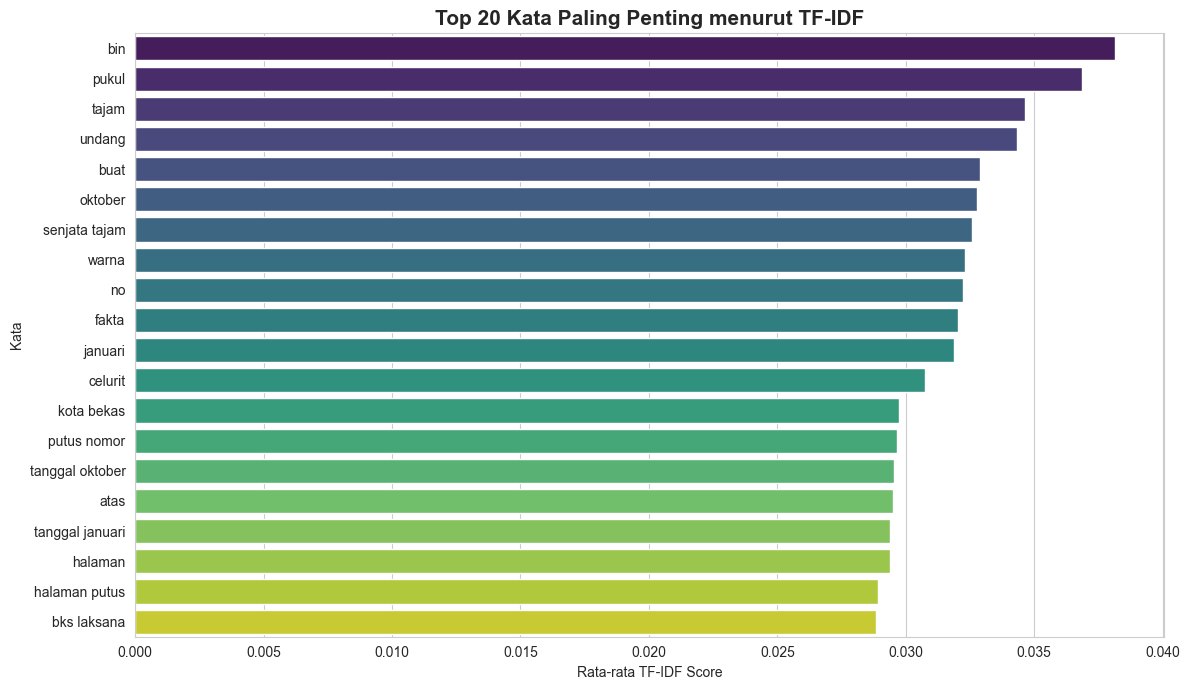


Menampilkan visualisasi hasil Retrieval...


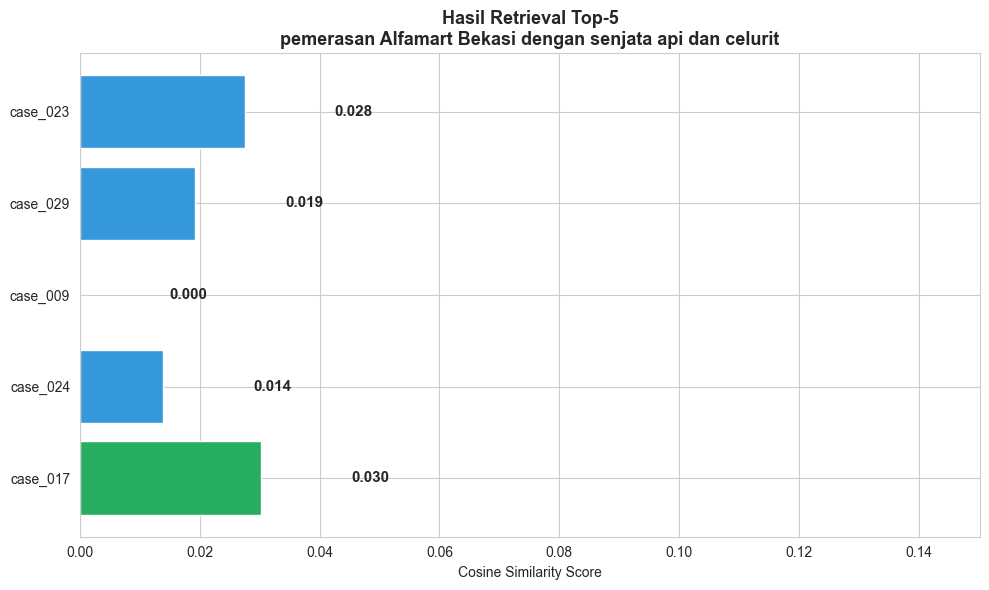

In [7]:
# ============================================================
# VISUALISASI TAHAP 3 (Jalankan setelah build_tfidf)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# ===================== VISUALISASI TF-IDF =====================
def show_tfidf_visualization(vectorizer, tfidf_matrix, top_n=20):
    feature_names = vectorizer.get_feature_names_out()
    mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
    
    top_indices = mean_tfidf.argsort()[-top_n:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = mean_tfidf[top_indices]
    
    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_scores, y=top_words, palette='viridis')
    plt.title(f"Top {top_n} Kata Paling Penting menurut TF-IDF", fontsize=15, fontweight='bold')
    plt.xlabel("Rata-rata TF-IDF Score")
    plt.ylabel("Kata")
    plt.tight_layout()
    plt.show()


# ===================== VISUALISASI RETRIEVAL =====================
def show_retrieval_visualization(query, top_case_ids, similarities, k=5):
    top_sim = similarities[:k]
    
    plt.figure(figsize=(10, 6))
    colors = ['#27ae60' if i == 0 else '#3498db' for i in range(k)]
    
    bars = plt.barh(range(k), top_sim[::-1], color=colors[::-1])
    plt.yticks(range(k), top_case_ids[::-1])
    plt.xlabel("Cosine Similarity Score")
    plt.title(f"Hasil Retrieval Top-{k}\n{query}", fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    
    for bar, score in zip(bars, top_sim[::-1]):
        plt.text(score + 0.015, bar.get_y() + bar.get_height()/2, 
                f"{score:.3f}", va='center', fontsize=11, fontweight='bold')
    
    plt.xlim(0, max(top_sim) + 0.12)
    plt.tight_layout()
    plt.show()


# ===================== JALANKAN VISUALISASI =====================

# Pastikan variabel ini sudah ada
print("Menampilkan visualisasi TF-IDF...")
show_tfidf_visualization(vectorizer, tfidf_matrix, top_n=20)

# Test Retrieval + Visualisasi
test_query = "pemerasan Alfamart Bekasi dengan senjata api dan celurit"
top_ids = retrieve(test_query, k=5)

similarities = cosine_similarity(
    vectorizer.transform([test_query]), 
    tfidf_matrix
).flatten()

print("\nMenampilkan visualisasi hasil Retrieval...")
show_retrieval_visualization(test_query, top_ids, similarities, k=5)

## Tahap 4 - Case Solution Reuse

Pada tahap ini dilakukan proses **Case Solution Reuse**, yaitu memanfaatkan solusi dari kasus-kasus terdahulu yang memiliki tingkat kemiripan tertinggi untuk memberikan rekomendasi penyelesaian terhadap suatu kasus baru.

Tahap ini merupakan implementasi dari komponen **Reuse** pada metode **Case-Based Reasoning (CBR)**. Setelah sistem berhasil menemukan beberapa kasus yang paling mirip pada tahap *Case Retrieval*, informasi mengenai **amar putusan** dari kasus-kasus tersebut digunakan sebagai dasar dalam memberikan prediksi solusi.

Proses yang dilakukan pada tahap ini meliputi:

### 1. Membangun Basis Solusi

Sistem terlebih dahulu membangun basis solusi (*Case Solution Base*) dari seluruh dokumen pada **Case Base**.

Untuk setiap kasus, solusi diambil berdasarkan prioritas berikut:

* **Amar putusan**, sebagai sumber utama karena merupakan keputusan akhir pengadilan.
* **Ringkasan fakta**, digunakan sebagai alternatif apabila amar putusan tidak tersedia.
* Pesan default akan diberikan apabila kedua informasi tersebut tidak ditemukan.

Dengan demikian, setiap `case_id` memiliki pasangan solusi yang dapat digunakan kembali pada proses prediksi.

---

### 2. Prediksi Solusi Kasus Baru

Ketika pengguna memasukkan sebuah query, sistem akan menjalankan proses berikut:

1. Melakukan pencarian **Top-5 kasus paling mirip** menggunakan fungsi `retrieve()` yang telah dibangun pada tahap sebelumnya.
2. Mengambil solusi (amar putusan) dari masing-masing kasus yang berhasil ditemukan.
3. Menampilkan seluruh solusi dari lima kasus tersebut sebagai referensi.
4. Menentukan **prediksi solusi** berdasarkan kasus dengan nilai kemiripan tertinggi.

Pada implementasi ini digunakan strategi **Nearest Neighbor**, yaitu solusi dari **kasus yang memiliki tingkat kemiripan tertinggi** dijadikan sebagai prediksi untuk kasus baru. Pendekatan ini dipilih karena merupakan metode yang paling sederhana dan umum digunakan pada implementasi awal **Case-Based Reasoning (CBR)**.

---

### 3. Pengujian Menggunakan Query Baru

Untuk menguji kemampuan sistem dalam memberikan rekomendasi solusi, digunakan lima query baru yang memiliki karakteristik serupa dengan kasus-kasus pada dataset.

Kelima query dipilih agar mewakili beberapa variasi tindak pidana, seperti:

* pemerasan menggunakan senjata api dan senjata tajam;
* kepemilikan senjata tajam tanpa izin;
* pencurian dengan kekerasan;
* membawa senjata tajam di tempat umum;
* perampokan menggunakan ancaman senjata tajam.

Query tersebut sengaja dibuat dalam bentuk **deskripsi singkat**, bukan menyalin isi putusan secara langsung, sehingga lebih mendekati kondisi penggunaan sistem oleh pengguna sebenarnya.

---

### 4. Penyimpanan Hasil Prediksi

Setelah proses prediksi selesai, sistem akan menyimpan hasil ke dalam file **`predictions.csv`** yang berisi:

* ID query;
* teks query;
* solusi yang diprediksi;
* lima kasus yang memiliki tingkat kemiripan tertinggi.

File tersebut dapat digunakan sebagai bahan analisis pada tahap evaluasi untuk mengetahui apakah solusi yang diberikan sistem sudah sesuai dengan karakteristik kasus yang dicari.


In [8]:
# ============================================================
# TAHAP 4: CASE SOLUTION REUSE
# ============================================================

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ==================== PATH ====================
RESULTS_DIR = Path("data/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_PATH = RESULTS_DIR / "predictions.csv"


def build_case_solutions() -> Dict[str, str]:
    """
    Membuat dictionary {case_id: solusi_text}
    Mengambil amar_putusan, jika kosong pakai ringkasan_fakta
    """
    df = load_cases()
    
    solutions = {}
    for _, row in df.iterrows():
        case_id = row['case_id']
        
        # Prioritas: amar_putusan > ringkasan_fakta
        solution = str(row.get('amar_putusan', '')).strip()
        
        if not solution or solution == 'nan':
            solution = str(row.get('ringkasan_fakta', '')).strip()[:500]
        
        if not solution:
            solution = "Tidak ada amar putusan yang tersedia."
        
        solutions[case_id] = solution
    
    logger.info(f"Berhasil membangun {len(solutions)} solusi kasus")
    return solutions


def predict_outcome(query: str, k: int = 5) -> Dict:
    """
    Memprediksi solusi (amar putusan) untuk query baru
    """
    # Ambil top-k case_id
    top_k_case_ids = retrieve(query, k=k)
    
    # Load solusi
    case_solutions = build_case_solutions()
    
    # Ambil solusi dari top-k
    solutions = []
    for cid in top_k_case_ids:
        sol = case_solutions.get(cid, "Solusi tidak ditemukan")
        solutions.append({
            "case_id": cid,
            "solution": sol[:800]   # batasi panjang
        })
    
    # ===================== ALGORITMA PREDIKSI =====================
    # Strategi: Ambil solusi dari kasus paling mirip (weighted by similarity)
    # Untuk simplicity, kita ambil solusi dari case_id pertama (paling mirip)
    
    if solutions:
        predicted_solution = solutions[0]['solution']
    else:
        predicted_solution = "Tidak dapat memprediksi solusi."
    
    result = {
        "query": query,
        "predicted_solution": predicted_solution,
        "top_5_case_ids": top_k_case_ids,
        "top_k_solutions": solutions
    }
    
    return result


def run_demo_predictions():
    """
    Menjalankan demo 5 query baru dan menyimpan ke CSV
    """
    demo_queries = [
        {
            "query_id": "Q001",
            "query_text": "pemerasan Alfamart dengan senjata api dan celurit di Bekasi"
        },
        {
            "query_id": "Q002",
            "query_text": "membawa celurit tanpa ijin untuk tawuran"
        },
        {
            "query_id": "Q003",
            "query_text": "pencurian dengan kekerasan di minimarket menggunakan parang"
        },
        {
            "query_id": "Q004",
            "query_text": "membawa golok di tempat umum tanpa surat ijin"
        },
        {
            "query_id": "Q005",
            "query_text": "perampokan toko dengan ancaman senjata tajam"
        }
    ]
    
    all_predictions = []
    
    for q in demo_queries:
        print(f"\n{'='*70}")
        print(f"Query ID : {q['query_id']}")
        print(f"Query    : {q['query_text']}")
        print('='*70)
        
        result = predict_outcome(q['query_text'], k=5)
        
        print("\nPredicted Solution (ringkasan):")
        print(result['predicted_solution'][:600] + "...")
        
        print(f"\nTop-5 Case IDs: {result['top_5_case_ids']}")
        
        # Simpan untuk CSV
        all_predictions.append({
            "query_id": q['query_id'],
            "query_text": q['query_text'],
            "predicted_solution": result['predicted_solution'],
            "top_5_case_ids": ", ".join(result['top_5_case_ids'])
        })
    
    # Simpan ke CSV
    df_pred = pd.DataFrame(all_predictions)
    df_pred.to_csv(PREDICTIONS_PATH, index=False, encoding='utf-8-sig')
    
    print(f"\n✅ Hasil prediksi disimpan di: {PREDICTIONS_PATH}")
    return df_pred


if __name__ == "__main__":
    print("=" * 70)
    print("TAHAP 4: CASE SOLUTION REUSE")
    print("=" * 70)
    
    run_demo_predictions()

2026-06-27 16:13:11,327 | INFO | Berhasil membangun 32 solusi kasus
2026-06-27 16:13:11,341 | INFO | Berhasil membangun 32 solusi kasus
2026-06-27 16:13:11,355 | INFO | Berhasil membangun 32 solusi kasus
2026-06-27 16:13:11,369 | INFO | Berhasil membangun 32 solusi kasus
2026-06-27 16:13:11,383 | INFO | Berhasil membangun 32 solusi kasus


TAHAP 4: CASE SOLUTION REUSE

Query ID : Q001
Query    : pemerasan Alfamart dengan senjata api dan celurit di Bekasi

Predicted Solution (ringkasan):
u1. Menyatakan Terdakwa SOMITRO TOTAL OSWALD AKAR Alias SOMITRO Bin TOTAL OSWALD AKAR telah terbukti secadra sah dan meyakinkan bersalah melakukan tindak pidana tanpa hak membawa, memiliki, menyimpan senjata api sebagaimana dakwaan tunggal Penuntut Umum; 2. Menjatuhkan pidana terhadap Teridakwa SOMITRO TOTAL OSWALD AKAR Alias SOMITRO Binb TOTAL OSWALD AKAR berupa pidana penjara selama 11 (sebelas) bulan Menetapkan masa penangkapan dan penahanan yang telah dijalani terdakwa dikurangkan seluruhnya dari pidana yang dijatuhkan; 3. Menetapkan Terdakwa tetap berada dalam tahanan; 4. MenyatakRan bara...

Top-5 Case IDs: ['case_017', 'case_024', 'case_009', 'case_029', 'case_023']

Query ID : Q002
Query    : membawa celurit tanpa ijin untuk tawuran

Predicted Solution (ringkasan):
Bahwa pada saat dilakukan penangkapan dan dilakukan penggeledahan 

TAHAP 5: MODEL EVALUATION + VISUALISASI


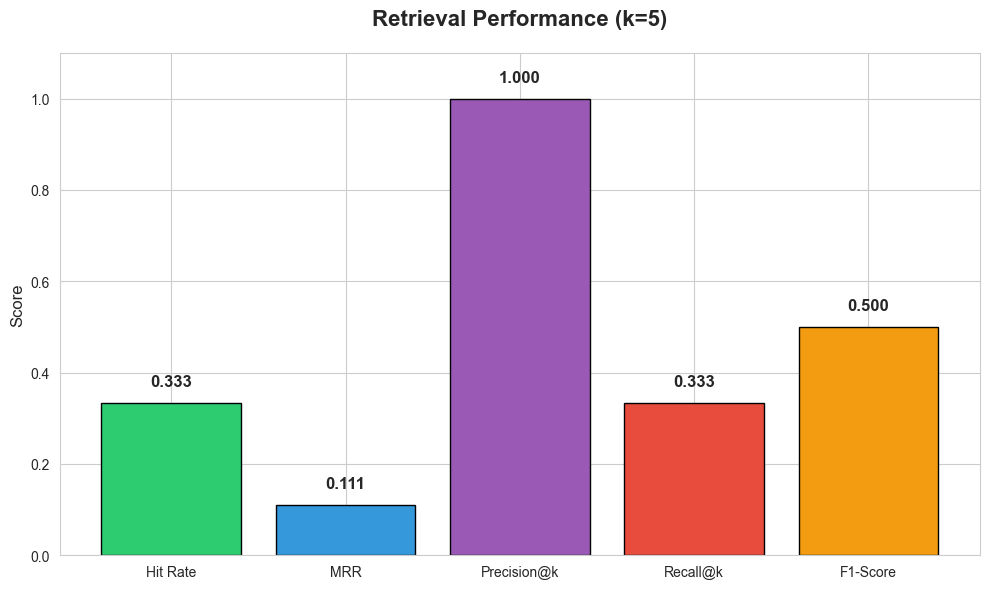


📋 DETAIL HASIL RETRIEVAL PER QUERY


,Query ID,Ground Truth,Hit?,Rank
0,Q001,case_001,True,3.000000
1,Q002,case_002,False,nan
2,Q004,case_027,False,nan


2026-06-27 16:13:11,794 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\Titan\AppData\Local\Temp\ipykernel_23808\2886453676.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=hit_ranks, palette='viridis')
2026-06-27 16:13:11,800 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


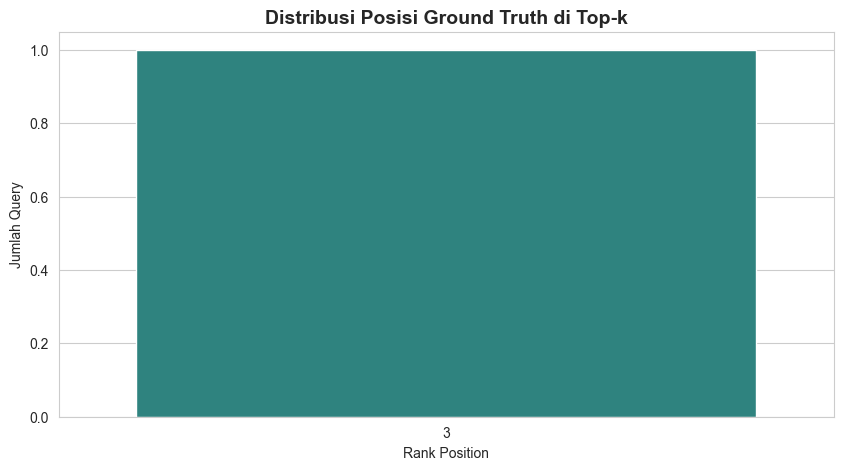


❌ ERROR ANALYSIS (Query yang Gagal)

Query ID : Q002
Query    : membawa celurit tanpa ijin di Bekasi...
Ground Truth: case_002
Top-k    : ['case_030', 'case_005', 'case_007', 'case_022', 'case_015']

Query ID : Q004
Query    : membawa celurit untuk tawuran di Bekasi...
Ground Truth: case_027
Top-k    : ['case_007', 'case_005', 'case_030', 'case_022', 'case_016']

📊 RINGKASAN EVALUASI
Total Query Dievaluasi : 3
Hit Rate @ 5        : 33.33%
MRR                    : 0.1111
Precision @ 5      : 1.0000
Recall @ 5         : 0.3333
F1-Score               : 0.5000


In [9]:
# ============================================================
# TAHAP 5: MODEL EVALUATION + VISUALISASI LENGKAP
# ============================================================

# Setup
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

EVAL_DIR = Path("data/eval")
RESULTS_DIR = Path("data/results")
EVAL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def load_queries():
    query_path = EVAL_DIR / "queries.json"
    if not query_path.exists():
        raise FileNotFoundError("Jalankan Tahap 3 dulu!")
    with open(query_path, "r", encoding="utf-8") as f:
        return json.load(f)


def eval_retrieval(queries: list, k: int = 5):
    y_true, y_pred = [], []
    hit_count = 0
    reciprocal_ranks = []
    results_detail = []

    for q in queries:
        query_text = q["query_text"]
        ground_truth = q.get("ground_truth_case_id")

        if not ground_truth:
            continue

        top_k = retrieve(query_text, k=k)
        is_hit = ground_truth in top_k

        if is_hit:
            hit_count += 1
            rank = top_k.index(ground_truth) + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0)

        y_true.append(1)
        y_pred.append(1 if is_hit else 0)

        results_detail.append({
            "query_id": q["query_id"],
            "query_text": query_text[:70] + "...",
            "ground_truth": ground_truth,
            "top_k": top_k,
            "hit": is_hit,
            "rank": rank if is_hit else None
        })

    total = len([q for q in queries if q.get("ground_truth_case_id")])
    hit_rate = hit_count / total if total > 0 else 0
    mrr = np.mean(reciprocal_ranks) if reciprocal_ranks else 0

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    metrics = {
        "k": k,
        "total_queries": total,
        "hit_rate": round(hit_rate, 4),
        "mrr": round(mrr, 4),
        "precision@k": round(precision, 4),
        "recall@k": round(recall, 4),
        "f1_score": round(f1, 4)
    }

    # Simpan detail
    pd.DataFrame(results_detail).to_csv(EVAL_DIR / "retrieval_detail.csv", index=False)
    pd.DataFrame([metrics]).to_csv(EVAL_DIR / "retrieval_metrics.csv", index=False)

    return metrics, results_detail


def visualize_evaluation(metrics: dict, detail: list):
    """Visualisasi lengkap dan detail"""
    
    # ===================== 1. BAR CHART METRIK =====================
    fig, ax = plt.subplots(figsize=(10, 6))
    
    metric_names = ['Hit Rate', 'MRR', 'Precision@k', 'Recall@k', 'F1-Score']
    metric_values = [
        metrics['hit_rate'], 
        metrics['mrr'], 
        metrics['precision@k'], 
        metrics['recall@k'], 
        metrics['f1_score']
    ]
    
    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12']
    bars = ax.bar(metric_names, metric_values, color=colors, edgecolor='black')
    
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(f"Retrieval Performance (k={metrics['k']})", fontsize=16, fontweight='bold', pad=20)
    
    for bar, val in zip(bars, metric_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
                f"{val:.3f}", ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(EVAL_DIR / "retrieval_metrics_chart.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ===================== 2. TABEL DETAIL (FIXED) =====================
    print("\n" + "="*100)
    print("📋 DETAIL HASIL RETRIEVAL PER QUERY")
    print("="*100)
    
    df_detail = pd.DataFrame(detail)
    display_df = df_detail[['query_id', 'ground_truth', 'hit', 'rank']].copy()
    display_df.columns = ['Query ID', 'Ground Truth', 'Hit?', 'Rank']
    
    # === PERBAIKAN DI SINI ===
    def color_hit(val):
        if val == True:
            return 'background-color: #d4edda; color: green; font-weight: bold'
        elif val == False:
            return 'background-color: #f8d7da; color: red; font-weight: bold'
        return ''
    
    styled = display_df.style.map(color_hit, subset=['Hit?'])
    display(styled)
    
    # ===================== 3. DISTRIBUSI RANK =====================
    hit_ranks = [d['rank'] for d in detail if d['rank'] is not None]
    
    if hit_ranks:
        plt.figure(figsize=(10, 5))
        sns.countplot(x=hit_ranks, palette='viridis')
        plt.title("Distribusi Posisi Ground Truth di Top-k", fontsize=14, fontweight='bold')
        plt.xlabel("Rank Position")
        plt.ylabel("Jumlah Query")
        plt.savefig(EVAL_DIR / "rank_distribution.png", dpi=300, bbox_inches='tight')
        plt.show()

    # ===================== 4. ERROR ANALYSIS =====================
    failed_queries = [d for d in detail if not d['hit']]
    
    print("\n" + "="*100)
    print("❌ ERROR ANALYSIS (Query yang Gagal)")
    print("="*100)
    
    if failed_queries:
        for fq in failed_queries:
            print(f"\nQuery ID : {fq['query_id']}")
            print(f"Query    : {fq['query_text']}")
            print(f"Ground Truth: {fq['ground_truth']}")
            print(f"Top-k    : {fq['top_k']}")
    else:
        print("✅ Semua query berhasil! Tidak ada kegagalan.")

    # ===================== 5. RINGKASAN =====================
    print("\n" + "="*100)
    print("📊 RINGKASAN EVALUASI")
    print("="*100)
    print(f"Total Query Dievaluasi : {metrics['total_queries']}")
    print(f"Hit Rate @ {metrics['k']}        : {metrics['hit_rate']:.2%}")
    print(f"MRR                    : {metrics['mrr']:.4f}")
    print(f"Precision @ {metrics['k']}      : {metrics['precision@k']:.4f}")
    print(f"Recall @ {metrics['k']}         : {metrics['recall@k']:.4f}")
    print(f"F1-Score               : {metrics['f1_score']:.4f}")
    print("="*100)


if __name__ == "__main__":
    print("=" * 70)
    print("TAHAP 5: MODEL EVALUATION + VISUALISASI")
    print("=" * 70)
    
    queries = load_queries()
    metrics, detail = eval_retrieval(queries, k=5)
    
    # Visualisasi lengkap
    visualize_evaluation(metrics, detail)